In [26]:
import pandas as pd
excl = pd.read_csv("../DATA/LOCAL/excl.csv")
hidden = pd.read_csv("../RESULT/final_selected_j_analysis_dataset.csv")

# TOP K에 대해

In [33]:
excl = pd.read_csv("../DATA/LOCAL/excl300.csv")

In [ ]:
import numpy as np
from sklearn.neighbors import BallTree

# 1. 데이터 로드

hidden = hidden.dropna(subset=["위도", "경도"]).copy()
excl = excl.dropna(subset=["위도", "경도"]).copy()

hidden = hidden.sort_values("selection_order")


# 2. 좌표 변환

EARTH_RADIUS_M = 6371000

excl_rad = np.radians(
    excl[["위도", "경도"]].values
)


# 3. 실험 범위

k_list = list(range(1, len(hidden)+1))

radius_list = [
    300,
    500,
    700,
    1000,
    1500,
    2000,
    3000,
    5000
]

results = []

# 4. Coverage 계산

for radius_m in radius_list:

    for k in k_list:

        selected_hidden = hidden.head(k)

        hidden_rad = np.radians(
            selected_hidden[["위도", "경도"]].values
        )

        tree = BallTree(hidden_rad, metric="haversine")

        dist, idx = tree.query(excl_rad, k=1)

        dist_m = dist[:, 0] * EARTH_RADIUS_M

        covered = dist_m <= radius_m

        coverage_count = covered.sum()

        coverage_rate = (
            coverage_count / len(excl)
        )

        results.append({
            "radius_m": radius_m,
            "K": k,
            "coverage_count": coverage_count,
            "coverage_rate": coverage_rate,
            "coverage_rate_pct": coverage_rate * 100,
            "avg_distance_m": dist_m.mean()
        })

coverage_df = pd.DataFrame(results)

display(coverage_df.head())

,radius_m,K,coverage_count,coverage_rate,coverage_rate_pct,avg_distance_m
0,300,1,0,0.0,0.0,9603.812418
1,300,2,0,0.0,0.0,8768.634485
2,300,3,0,0.0,0.0,7958.682681
3,300,4,0,0.0,0.0,7854.969926
4,300,5,0,0.0,0.0,7834.143073


In [37]:
coverage_df.to_csv("exclude_coverage.csv")

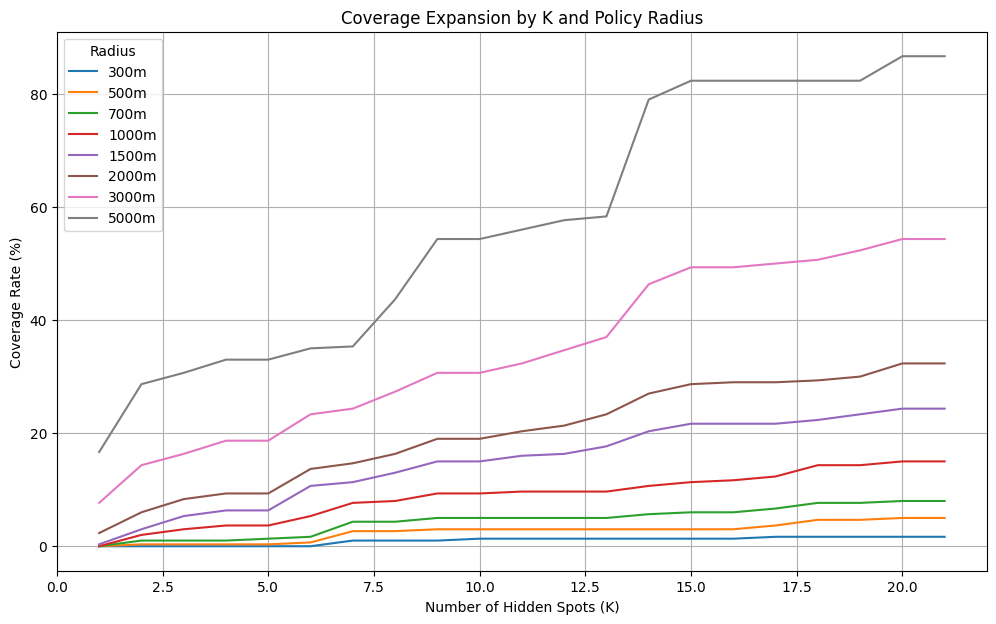

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))

for radius in radius_list:

    temp = coverage_df[
        coverage_df["radius_m"] == radius
    ]

    plt.plot(
        temp["K"],
        temp["coverage_rate_pct"],
        label=f"{radius}m"
    )

plt.xlabel("Number of Hidden Spots (K)")
plt.ylabel("Coverage Rate (%)")

plt.title(
    "Coverage Expansion by K and Policy Radius"
)

plt.legend(title="Radius")

plt.grid(True)

plt.show()

In [39]:
hidden = hidden.sort_values("selection_order").reset_index(drop=True)

EARTH_RADIUS_M = 6371000
radius_m = 1500

excl_rad = np.radians(excl[["위도", "경도"]].values)

results = []

for k in range(1, len(hidden) + 1):
    selected_hidden = hidden.head(k).copy()
    
    hidden_rad = np.radians(
        selected_hidden[["위도", "경도"]].values
    )
    
    tree = BallTree(hidden_rad, metric="haversine")
    
    dist, idx = tree.query(excl_rad, k=1)
    dist_m = dist[:, 0] * EARTH_RADIUS_M
    
    covered = dist_m <= radius_m
    coverage_count = covered.sum()
    coverage_rate = coverage_count / len(excl)
    
    results.append({
        "K": k,
        "covered_excl_count": coverage_count,
        "total_excl_count": len(excl),
        "coverage_rate": coverage_rate,
        "coverage_rate_pct": coverage_rate * 100,
        "avg_nearest_distance_m": dist_m.mean()
    })

coverage_1500_df = pd.DataFrame(results)

# marginal gain 계산

coverage_1500_df["marginal_gain_count"] = (
    coverage_1500_df["covered_excl_count"].diff().fillna(
        coverage_1500_df["covered_excl_count"]
    )
)

coverage_1500_df["marginal_gain_pct"] = (
    coverage_1500_df["coverage_rate_pct"].diff().fillna(
        coverage_1500_df["coverage_rate_pct"]
    )
)

display(coverage_1500_df)

,K,covered_excl_count,total_excl_count,coverage_rate,coverage_rate_pct,avg_nearest_distance_m,marginal_gain_count,marginal_gain_pct
0,1,1,300,0.003333,0.333333,9603.812418,1.0,0.333333
1,2,9,300,0.030000,3.000000,8768.634485,8.0,2.666667
2,3,16,300,0.053333,5.333333,7958.682681,7.0,2.333333
3,4,19,300,0.063333,6.333333,7854.969926,3.0,1.000000
4,5,19,300,0.063333,6.333333,7834.143073,0.0,0.000000
5,6,32,300,0.106667,10.666667,7504.580361,13.0,4.333333
6,7,34,300,0.113333,11.333333,7290.322441,2.0,0.666667
7,8,39,300,0.130000,13.000000,6033.012586,5.0,1.666667
8,9,45,300,0.150000,15.000000,5153.529305,6.0,2.000000
9,10,45,300,0.150000,15.000000,5151.394521,0.0,0.000000


In [40]:

excl = excl.sort_values(
    "종합점수_40_30_30",
    ascending=False
).reset_index(drop=True)

EARTH_RADIUS_M = 6371000
radius_m = 1500

hidden_rad = np.radians(
    hidden[["위도", "경도"]].values
)

tree = BallTree(hidden_rad, metric="haversine")


topk_list = [
    10,
    20,
    30,
    50,
    100,
    150,
    200,
    300
]

results = []

for topk in topk_list:

    excl_topk = excl.head(topk).copy()

    excl_rad = np.radians(
        excl_topk[["위도", "경도"]].values
    )

    dist, idx = tree.query(excl_rad, k=1)

    dist_m = dist[:, 0] * EARTH_RADIUS_M

    covered = dist_m <= radius_m

    coverage_count = covered.sum()

    coverage_rate = (
        coverage_count / topk
    )

    results.append({
        "topk_excluded_area": topk,
        "covered_count": coverage_count,
        "coverage_rate": coverage_rate,
        "coverage_rate_pct": coverage_rate * 100,
        "avg_distance_m": dist_m.mean()
    })

coverage_topk_df = pd.DataFrame(results)

display(coverage_topk_df)

,topk_excluded_area,covered_count,coverage_rate,coverage_rate_pct,avg_distance_m
0,10,3,0.300000,30.000000,2558.706701
1,20,6,0.300000,30.000000,2892.926067
2,30,9,0.300000,30.000000,2908.107709
3,50,17,0.340000,34.000000,2636.415151
4,100,32,0.320000,32.000000,2753.526058
5,150,39,0.260000,26.000000,2897.211981
6,200,52,0.260000,26.000000,2947.787128
7,300,73,0.243333,24.333333,2956.738847


In [41]:
excl = excl.sort_values(
    "종합점수_40_30_30",
    ascending=False
).reset_index(drop=True)

EARTH_RADIUS_M = 6371000

hidden_rad = np.radians(
    hidden[["위도", "경도"]].values
)

tree = BallTree(hidden_rad, metric="haversine")

topk_list = [10, 20, 30, 50, 100, 150, 200, 300]

radius_list = [
    300,
    500,
    700,
    1000,
    1200,
    1500
]

results = []

for topk in topk_list:
    excl_topk = excl.head(topk).copy()

    excl_rad = np.radians(
        excl_topk[["위도", "경도"]].values
    )

    dist, idx = tree.query(excl_rad, k=1)
    dist_m = dist[:, 0] * EARTH_RADIUS_M

    for radius_m in radius_list:
        covered = dist_m <= radius_m
        coverage_count = covered.sum()
        coverage_rate = coverage_count / topk

        results.append({
            "topk_excluded_area": topk,
            "radius_m": radius_m,
            "covered_count": coverage_count,
            "total_count": topk,
            "coverage_rate": coverage_rate,
            "coverage_rate_pct": coverage_rate * 100,
            "avg_distance_m": dist_m.mean()
        })

coverage_topk_radius_df = pd.DataFrame(results)

display(coverage_topk_radius_df)

,topk_excluded_area,radius_m,covered_count,total_count,coverage_rate,coverage_rate_pct,avg_distance_m
0,10,300,0,10,0.000000,0.000000,2558.706701
1,10,500,0,10,0.000000,0.000000,2558.706701
2,10,700,1,10,0.100000,10.000000,2558.706701
3,10,1000,2,10,0.200000,20.000000,2558.706701
4,10,1200,2,10,0.200000,20.000000,2558.706701
5,10,1500,3,10,0.300000,30.000000,2558.706701
6,20,300,1,20,0.050000,5.000000,2892.926067
7,20,500,1,20,0.050000,5.000000,2892.926067
8,20,700,2,20,0.100000,10.000000,2892.926067
9,20,1000,4,20,0.200000,20.000000,2892.926067


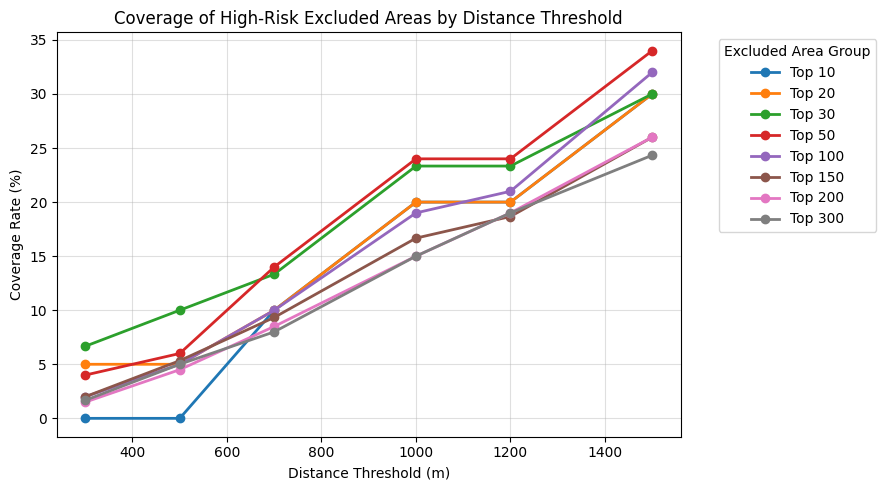

In [42]:
# Distance threshold별 coverage curve
plt.figure(figsize=(9, 5))

for topk in topk_list:
    temp = coverage_topk_radius_df[
        coverage_topk_radius_df["topk_excluded_area"] == topk
    ]

    plt.plot(
        temp["radius_m"],
        temp["coverage_rate_pct"],
        marker="o",
        linewidth=2,
        label=f"Top {topk}"
    )

plt.xlabel("Distance Threshold (m)")
plt.ylabel("Coverage Rate (%)")
plt.title("Coverage of High-Risk Excluded Areas by Distance Threshold")

plt.grid(True, alpha=0.4)
plt.legend(title="Excluded Area Group", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [43]:
coverage_pivot = coverage_topk_radius_df.pivot(
    index="topk_excluded_area",
    columns="radius_m",
    values="coverage_rate_pct"
)

coverage_pivot = coverage_pivot.round(2)

display(coverage_pivot)

radius_m,300,500,700,1000,1200,1500
topk_excluded_area,,,,,,
10,0.00,0.00,10.00,20.00,20.00,30.00
20,5.00,5.00,10.00,20.00,20.00,30.00
30,6.67,10.00,13.33,23.33,23.33,30.00
50,4.00,6.00,14.00,24.00,24.00,34.00
100,2.00,5.00,10.00,19.00,21.00,32.00
150,2.00,5.33,9.33,16.67,18.67,26.00
200,1.50,4.50,8.50,15.00,19.00,26.00
300,1.67,5.00,8.00,15.00,19.00,24.33


In [44]:
coverage_topk_radius_df.to_csv(
    "coverage_topk_radius_hidden_spot.csv",
    index=False,
    encoding="utf-8-sig"
)

coverage_pivot.to_csv(
    "coverage_topk_radius_pivot.csv",
    encoding="utf-8-sig"
)